# **Importing Data from Kagglehub**
This dataset explores how artificial intelligence is transforming student life, focusing on study habits, academic performance, and overall satisfaction. It provides insights into how students interact with AI tools in their daily learning routines and how these tools influence their outcomes

The dataset highlights real-world usage patterns and reveals both the benefits and potential drawbacks of AI adoption in education.

In [19]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumeakash/how-ai-is-changing-student-life")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'how-ai-is-changing-student-life' dataset.
Path to dataset files: /kaggle/input/how-ai-is-changing-student-life


# **Importing libraries**
pandas
,numpy
, matplotlib
, seaborn

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_palette("Set2")

In [21]:
import os

# List contents of the downloaded directory to find the actual CSV file
file_list = os.listdir(path)
print("Files in dataset directory:", file_list)

# Assuming the CSV file is the first (or only) file in the directory
# If there are multiple CSVs, you might need to specify the correct one.
csv_file_name = [f for f in file_list if f.endswith('.csv')][0]
full_csv_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_csv_path)
print("Shape:", df.shape)
display(df.head())

Files in dataset directory: ['AI_Student_Life_india.csv']
Shape: (400, 10)


,Student_ID,Age,Gender,Education_Level,City,AI_Tool_Used,Daily_Usage_Hours,Purpose,Impact_on_Grades,Satisfaction_Level
0,1,15,Female,College,Hyderabad,Copilot,1.1,Learning,Slight Decline,Medium
1,2,21,Female,University,Chennai,Copilot,1.7,Coding,Slight Decline,High
2,3,22,Male,University,Bangalore,Gemini,1.5,Learning,Improved,Low
3,4,22,Male,College,Hyderabad,ChatGPT,3.8,Research,Improved,Low
4,5,22,Male,College,Hyderabad,Gemini,5.2,Coding,Slight Decline,Low


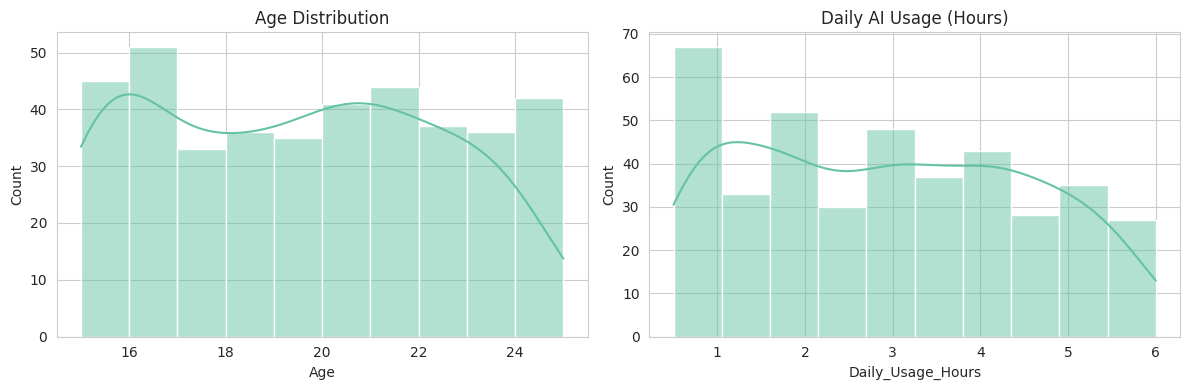

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["Age"], bins=10, kde=True)
plt.title("Age Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df["Daily_Usage_Hours"], bins=10, kde=True)
plt.title("Daily AI Usage (Hours)")

plt.tight_layout()
plt.show()

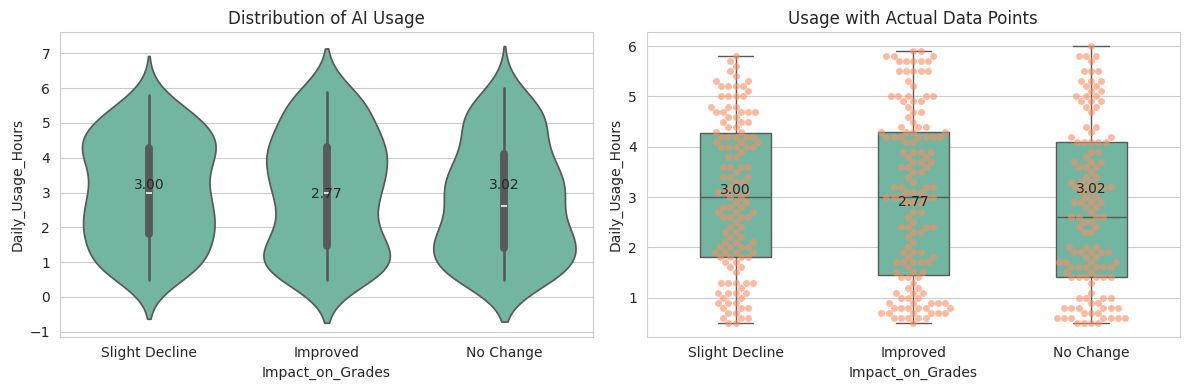

In [23]:
plt.figure(figsize=(12, 4))

# Violin (distribution)
plt.subplot(1, 2, 1)
ax1 = sns.violinplot(x="Impact_on_Grades", y="Daily_Usage_Hours", data=df)

means = df.groupby("Impact_on_Grades")["Daily_Usage_Hours"].mean()
for i, mean in enumerate(means):
    ax1.text(i, mean, f"{mean:.2f}", ha="center", va="bottom")

plt.title("Distribution of AI Usage")

# Box + swarm (actual points)
plt.subplot(1, 2, 2)
sns.boxplot(x="Impact_on_Grades", y="Daily_Usage_Hours", data=df, width=0.4)
sns.swarmplot(x="Impact_on_Grades", y="Daily_Usage_Hours", data=df, alpha=0.6)

for i, mean in enumerate(means):
    plt.text(i, mean, f"{mean:.2f}", ha="center", va="bottom")

plt.title("Usage with Actual Data Points")


plt.tight_layout()
plt.show()

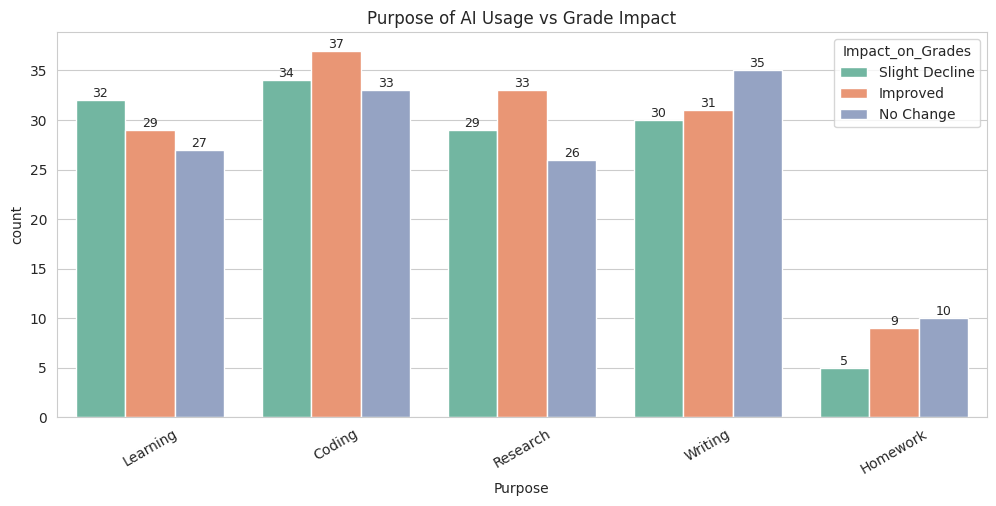

In [24]:
plt.figure(figsize=(12, 5))
ax = sns.countplot(x="Purpose", hue="Impact_on_Grades", data=df)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.xticks(rotation=30)
plt.title("Purpose of AI Usage vs Grade Impact")
plt.show()

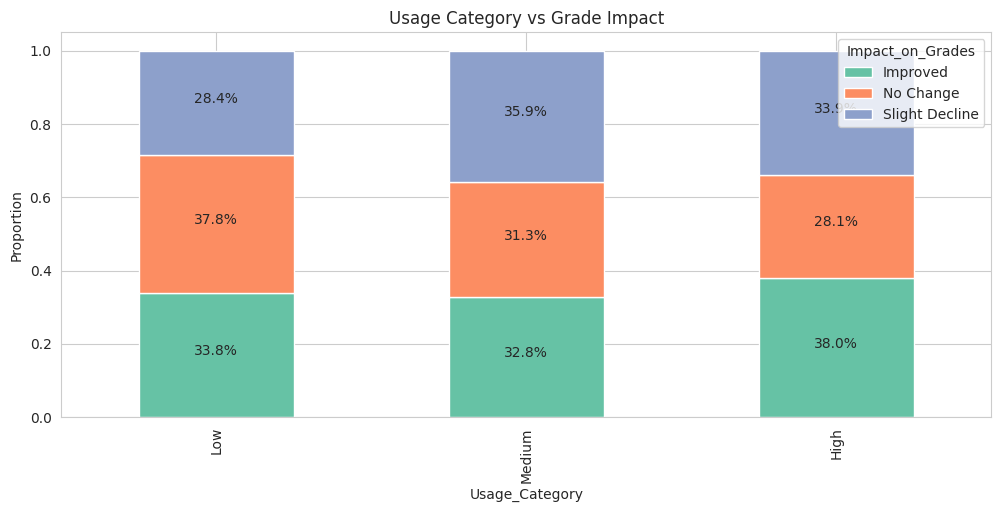

In [25]:
df["Usage_Category"] = pd.cut(
    df["Daily_Usage_Hours"], bins=[0, 2, 4, 6], labels=["Low", "Medium", "High"]
)

usage_ct = pd.crosstab(df["Usage_Category"], df["Impact_on_Grades"], normalize="index")

usage_ct.plot(kind="bar", stacked=True, figsize=(12, 5))

for i, row in enumerate(usage_ct.values):
    cumulative = 0
    for val in row:
        if val > 0.05:
            plt.text(i, cumulative + val / 2, f"{val*100:.1f}%", ha="center")
        cumulative += val

plt.title("Usage Category vs Grade Impact")
plt.ylabel("Proportion")
plt.show()

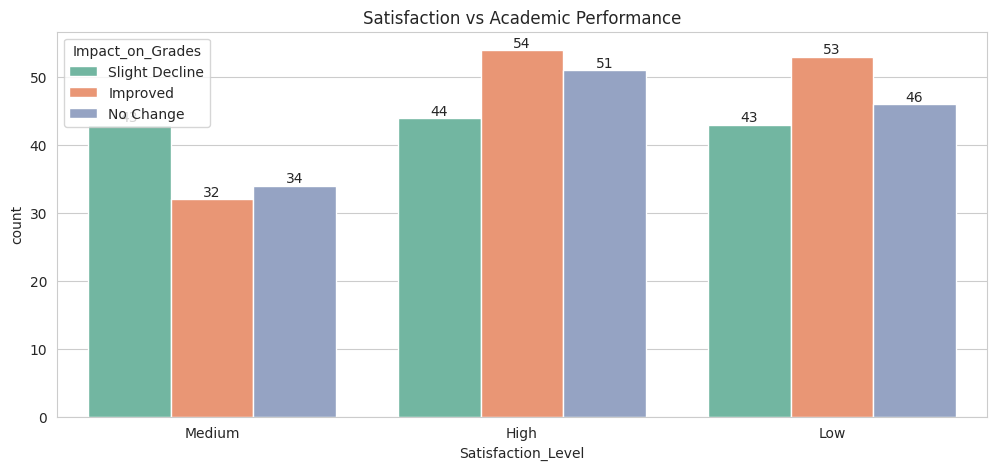

In [26]:
plt.figure(figsize=(12, 5))
ax = sns.countplot(x="Satisfaction_Level", hue="Impact_on_Grades", data=df)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
        )

plt.title("Satisfaction vs Academic Performance")
plt.show()

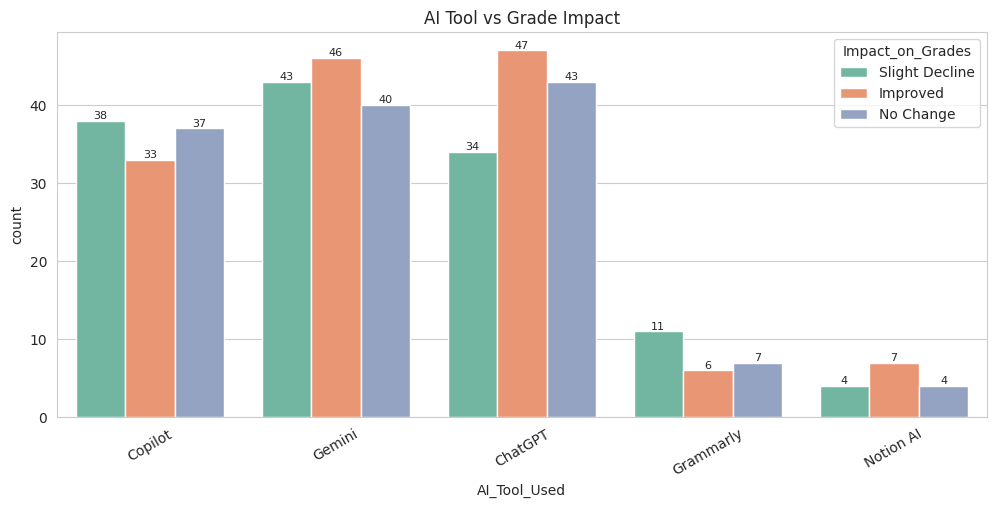

In [27]:
plt.figure(figsize=(12, 5))
ax = sns.countplot(x="AI_Tool_Used", hue="Impact_on_Grades", data=df)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=8,
        )

plt.xticks(rotation=30)
plt.title("AI Tool vs Grade Impact")
plt.show()

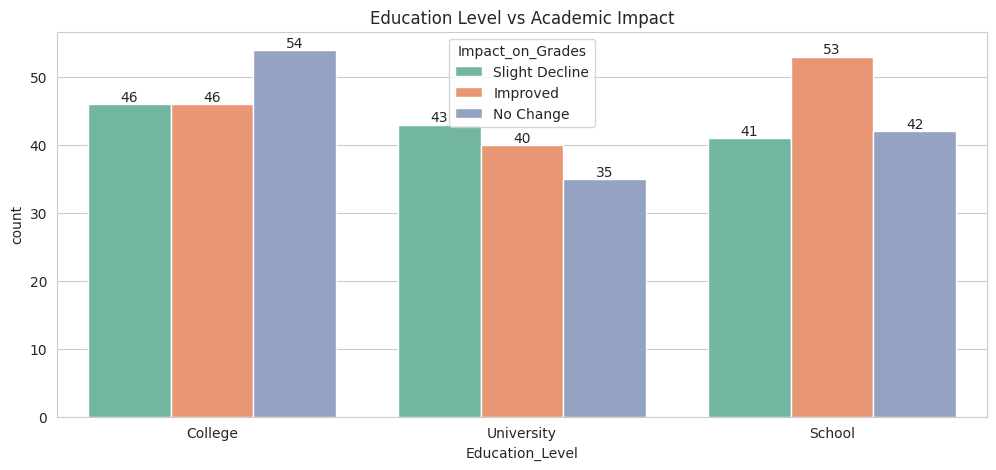

In [28]:
plt.figure(figsize=(12, 5))
ax = sns.countplot(x="Education_Level", hue="Impact_on_Grades", data=df)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
        )

plt.title("Education Level vs Academic Impact")
plt.show()

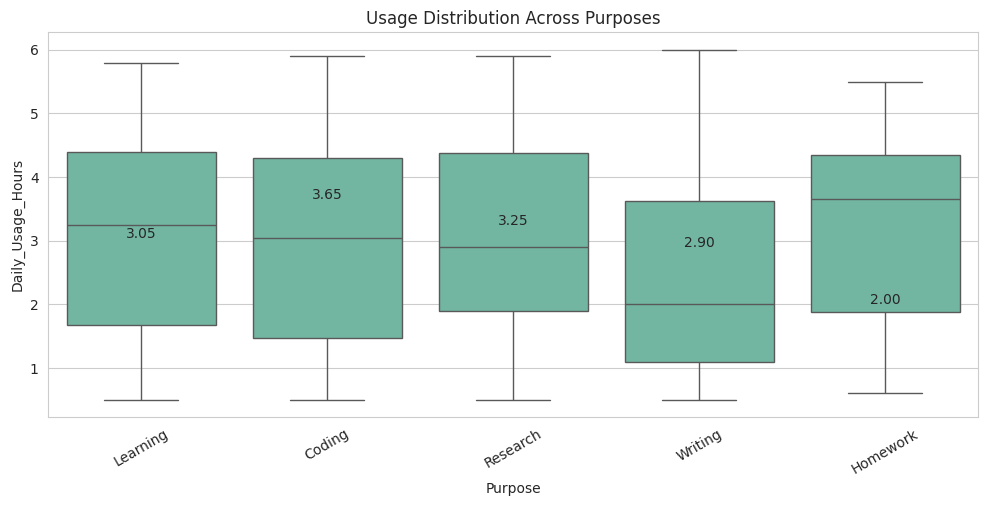

In [29]:
plt.figure(figsize=(12, 5))
ax = sns.boxplot(x="Purpose", y="Daily_Usage_Hours", data=df)

medians = df.groupby("Purpose")["Daily_Usage_Hours"].median()
for i, median in enumerate(medians):
    ax.text(i, median, f"{median:.2f}", ha="center")

plt.xticks(rotation=30)
plt.title("Usage Distribution Across Purposes")
plt.show()

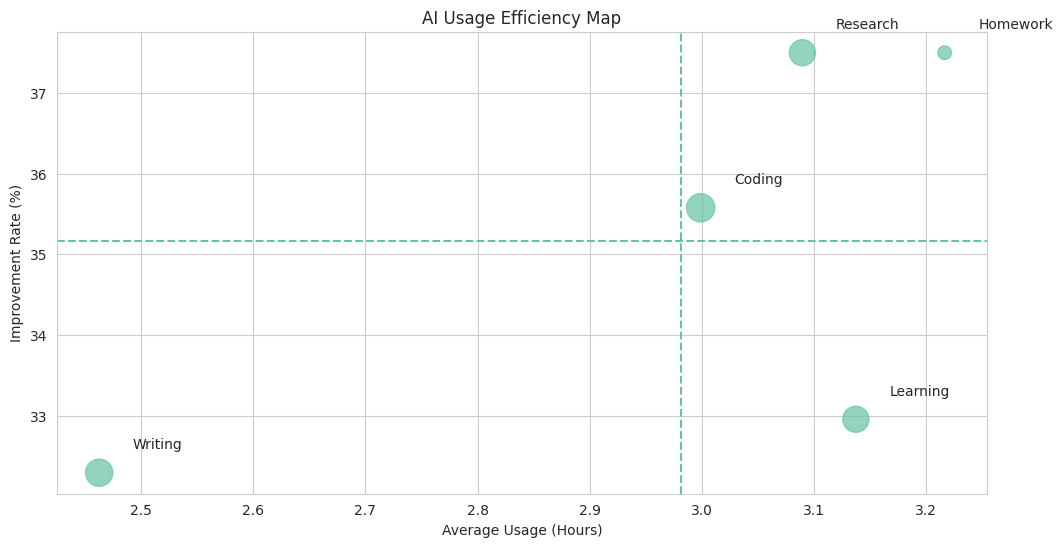

In [30]:
summary = (
    df.groupby("Purpose")
    .agg(
        avg_usage=("Daily_Usage_Hours", "mean"),
        improved_rate=("Impact_on_Grades", lambda x: (x == "Improved").mean() * 100),
        count=("Purpose", "count"),
    )
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.scatter(
    summary["avg_usage"], summary["improved_rate"], s=summary["count"] * 4, alpha=0.7
)

for _, row in summary.iterrows():
    plt.text(row["avg_usage"] + 0.03, row["improved_rate"] + 0.3, row["Purpose"])

# quadrant lines
plt.axvline(summary["avg_usage"].mean(), linestyle="--")
plt.axhline(summary["improved_rate"].mean(), linestyle="--")

plt.xlabel("Average Usage (Hours)")
plt.ylabel("Improvement Rate (%)")
plt.title("AI Usage Efficiency Map")

plt.grid(True)
plt.show()

In [31]:
!pip install ydata-profiling

In [32]:
from ydata_profiling import ProfileReport

report = ProfileReport(df, title="Profiling Report")
report.to_file("Profiling_Report.html")
report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 47.33it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]